# DeepExtractor — Glitch Reconstruction Tutorial

This notebook demonstrates how to reconstruct real glitches from LIGO's O3 observing run using DeepExtractor.
We fetch open data from GWOSC, whiten it, and call `model.reconstruct()` to obtain glitch estimates for
two canonical classes: **Blip** and **Scattered Light**.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import scienceplots
import importlib

from gwpy.timeseries import TimeSeries
from pycbc.types import TimeSeries as TimeSeries_pycbc

import deepextractor
from deepextractor.utils.checkpoints import CHECKPOINT_REAL
from deepextractor.utils.visualization import plot_q_transform
from deepextractor.utils.signal import custom_whiten

plt.style.use(['science'])
plt.rcParams['text.usetex'] = False

TimeSeries_pycbc.custom_whiten = custom_whiten

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [ ]:
import importlib.resources as pkg_resources

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_RATE = 4096

# Resolve bundled assets from the installed package
_assets = pkg_resources.files("deepextractor") / "assets"
ASSETS_DIR = str(_assets)

# Bundled GravitySpy O3a sample (10 high-SNR H1 examples per class)
# Source: GravitySpy LIGO O3a high-confidence dataset — https://doi.org/10.5281/zenodo.1476551
GRAVITY_SPY_CSV = str(_assets / "data_o3a_sample.csv")

## Gravity Spy dataset

We use a bundled sample of the high-confidence GravitySpy O3a catalogue to identify specific
glitch events by GPS time. This is a real subset of the
[GravitySpy LIGO O3a dataset](https://doi.org/10.5281/zenodo.1476551), containing
10 high-SNR H1 examples per glitch class. Each row records the GPS time of a glitch trigger,
its SNR, and its GravitySpy label.
We pick one Blip and one Scattered Light event for reconstruction.


In [5]:
# Load the bundled GravitySpy O3a sample
# Real subset of the GravitySpy LIGO O3a high-confidence dataset
# (10 highest-SNR H1 examples per class)
data_o3a = pd.read_csv(GRAVITY_SPY_CSV)
data_o3a = data_o3a.drop_duplicates(subset=['GPStime'])

h1_data     = data_o3a[data_o3a.ifo == 'H1']
blip_row    = h1_data[h1_data.label == 'Blip'].iloc[0]
scatter_row = h1_data[h1_data.label == 'Scattered_Light'].iloc[2]

print(f"Blip            GPS: {blip_row.GPStime:.3f},  SNR: {blip_row.snr:.1f}")
print(f"Scattered Light GPS: {scatter_row.GPStime:.3f},  SNR: {scatter_row.snr:.1f}")
print(f"\nAvailable glitch classes ({data_o3a['label'].nunique()} total):")
print(", ".join(sorted(data_o3a['label'].unique())))


Blip            GPS: 1252747032.963,  SNR: 45.9
Scattered Light GPS: 1243975564.438,  SNR: 28.0

Available glitch classes (17 total):
Blip, Blip_Low_Frequency, Extremely_Loud, Fast_Scattering, Koi_Fish, Light_Modulation, Low_Frequency_Burst, Low_Frequency_Lines, No_Glitch, Paired_Doves, Power_Line, Repeating_Blips, Scattered_Light, Scratchy, Tomte, Violin_Mode, Whistle


## Load DeepExtractor

We use the real-data fine-tuned checkpoint (`CHECKPOINT_REAL`) paired with the corresponding `scaler.pkl`.
Weights are downloaded automatically from Hugging Face Hub on first use.

In [ ]:
model = deepextractor.DeepExtractorModel(
    checkpoint_filename=CHECKPOINT_REAL,
    scaler_path=str(_assets / "scaler.pkl"),
    device=DEVICE,
)
print(f"Model loaded on: {model.device}")

## Reconstruction

For each event we:
1. Fetch 14 s of open strain data centred on the GPS trigger time.
2. Estimate the PSD from the 14 s *before* the glitch window.
3. Whiten the glitch window using that PSD.
4. Extract the central 2 s and call `model.reconstruct()` — which handles scaling, STFT, U-Net inference, iSTFT, and inverse scaling internally.
5. Subtracting the reconstruction from the input gives the cleaned strain.

In [7]:
def fetch_and_reconstruct(gps_time, ifo, sample_rate=SAMPLE_RATE, max_retries=3):
    """Fetch open data for a glitch event and reconstruct it with DeepExtractor."""
    for attempt in range(max_retries):
        try:
            psd_segment = TimeSeries.fetch_open_data(
                ifo, gps_time - 21, gps_time - 7, sample_rate=sample_rate
            )
            glitch = TimeSeries.fetch_open_data(
                ifo, gps_time - 7, gps_time + 7, sample_rate=sample_rate
            )
            break
        except Exception as e:
            if attempt == max_retries - 1:
                raise RuntimeError(f"Failed to fetch data for GPS {gps_time}: {e}")

    psd_pycbc    = TimeSeries_pycbc(np.asarray(psd_segment), delta_t=1.0 / sample_rate)
    glitch_pycbc = TimeSeries_pycbc(np.asarray(glitch),      delta_t=1.0 / sample_rate)

    _, psd          = psd_pycbc.whiten(2, 1, remove_corrupted=False, return_psd=True)
    white_glitch, _ = glitch_pycbc.custom_whiten(psd, return_psd=True)
    white_glitch    = np.asarray(white_glitch)

    mid            = len(white_glitch) // 2
    white_centered = white_glitch[mid - sample_rate : mid + sample_rate]

    g_hat = model.reconstruct(white_centered)

    return {'h_full': white_glitch, 'h_centered': white_centered, 'g_reconstructed': g_hat}


print("Fetching Blip ...")
blip = fetch_and_reconstruct(blip_row.GPStime, 'H1')

print("Fetching Scattered Light ...")
scatter = fetch_and_reconstruct(scatter_row.GPStime, 'H1')

Fetching Blip ...
Fetching Scattered Light ...


## Time-series plots

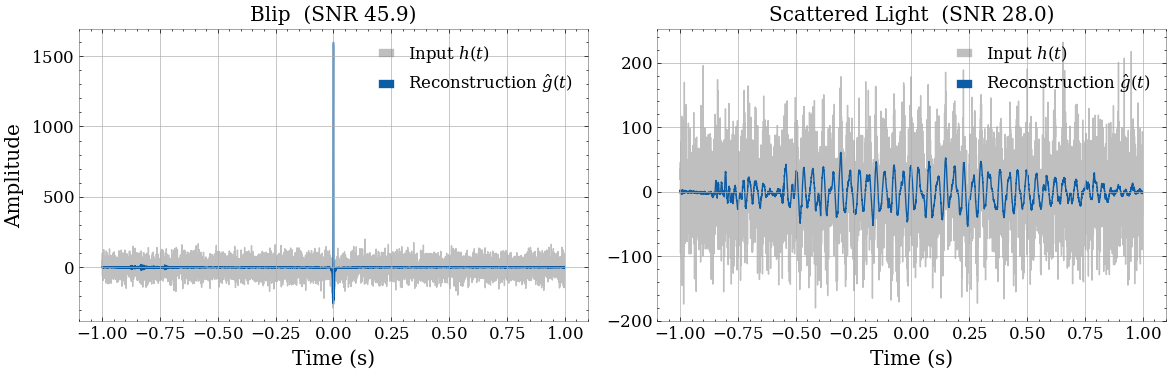

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t = np.linspace(-1, 1, 2 * SAMPLE_RATE)

examples = [
    (blip,    f'Blip  (SNR {blip_row.snr:.1f})'),
    (scatter, f'Scattered Light  (SNR {scatter_row.snr:.1f})'),
]

for ax, (result, title) in zip(axes, examples):
    ax.plot(t, result['h_centered'],   color='gray', alpha=0.5, label=r'Input $h(t)$')
    ax.plot(t, result['g_reconstructed'], color='C0', label=r'Reconstruction $\hat{g}(t)$')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.legend()
    ax.grid(True)

axes[0].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

## Glitch mitigation — Q-scans

Subtracting the reconstruction from the full 14 s whitened strain suppresses the glitch.
The Q-scans below show the strain **before** (top row) and **after** (middle row) glitch subtraction,
with the corresponding time series (bottom row).

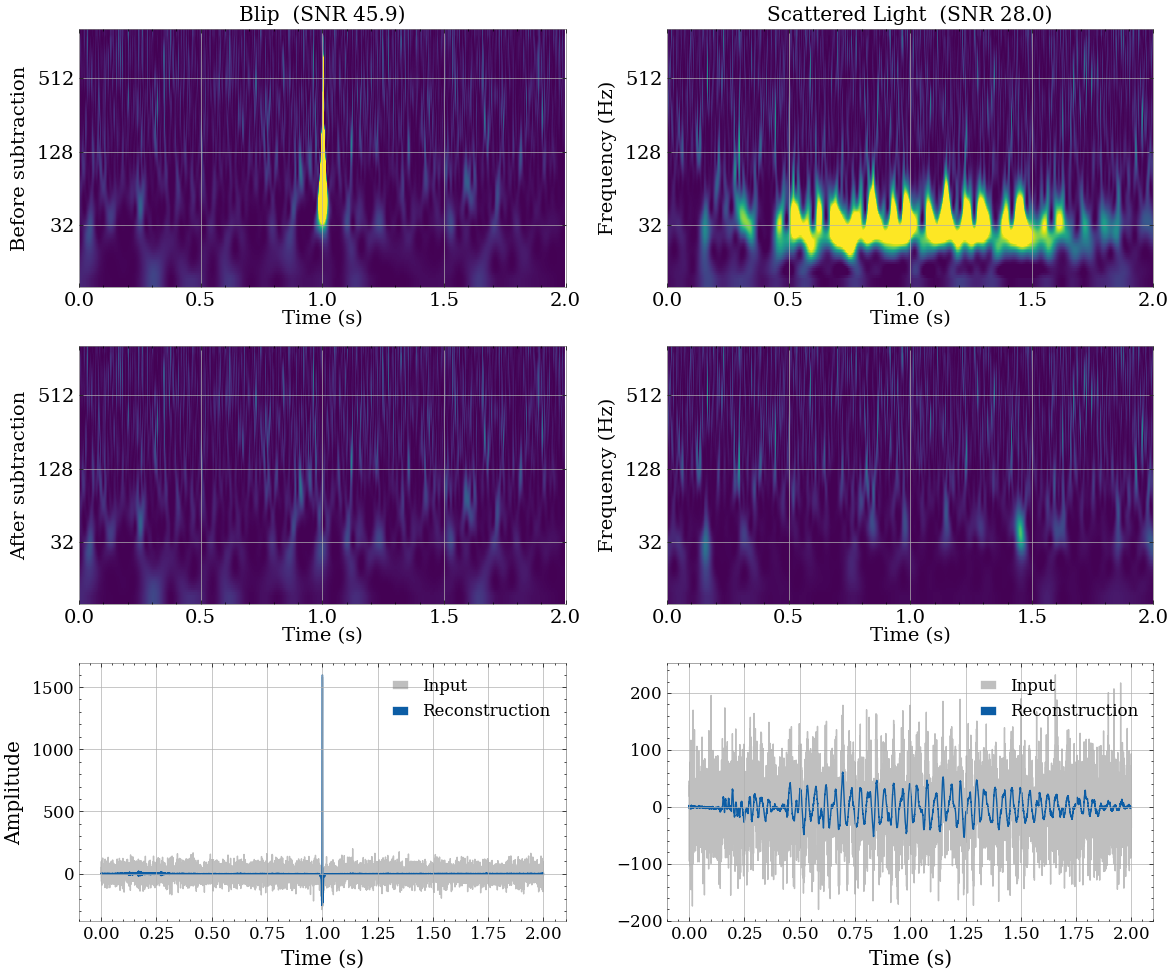

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
t = np.linspace(0, 2, 2 * SAMPLE_RATE)

examples = [
    (blip,    f'Blip  (SNR {blip_row.snr:.1f})'),
    (scatter, f'Scattered Light  (SNR {scatter_row.snr:.1f})'),
]

for col, (result, title) in enumerate(examples):
    h_full   = result['h_full']
    g_hat    = result['g_reconstructed']
    mid      = len(h_full) // 2
    t_centre = len(h_full) / SAMPLE_RATE / 2

    cleaned = h_full.copy()
    cleaned[mid - SAMPLE_RATE : mid + SAMPLE_RATE] -= g_hat

    plot_q_transform(h_full,  crop=(t_centre, 2), ax=axes[0, col], colourbar=False, whiten=False, qrange = [4,4])
    axes[0, col].set_title(title)

    plot_q_transform(cleaned, crop=(t_centre, 2), ax=axes[1, col], colourbar=False, whiten=False, qrange = [4,4])

    axes[2, col].plot(t, result['h_centered'],    color='gray', alpha=0.5, label='Input')
    axes[2, col].plot(t, g_hat,                   color='C0',   label='Reconstruction')
    axes[2, col].set_xlabel('Time (s)')
    axes[2, col].legend()
    axes[2, col].grid(True)

axes[0, 0].set_ylabel('Before subtraction')
axes[1, 0].set_ylabel('After subtraction')
axes[2, 0].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()